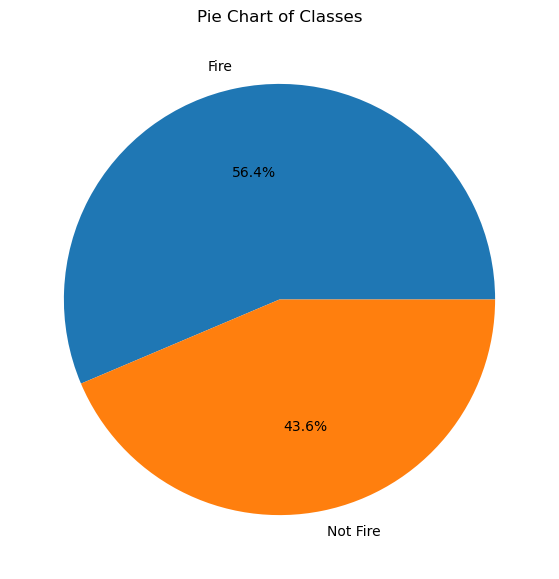

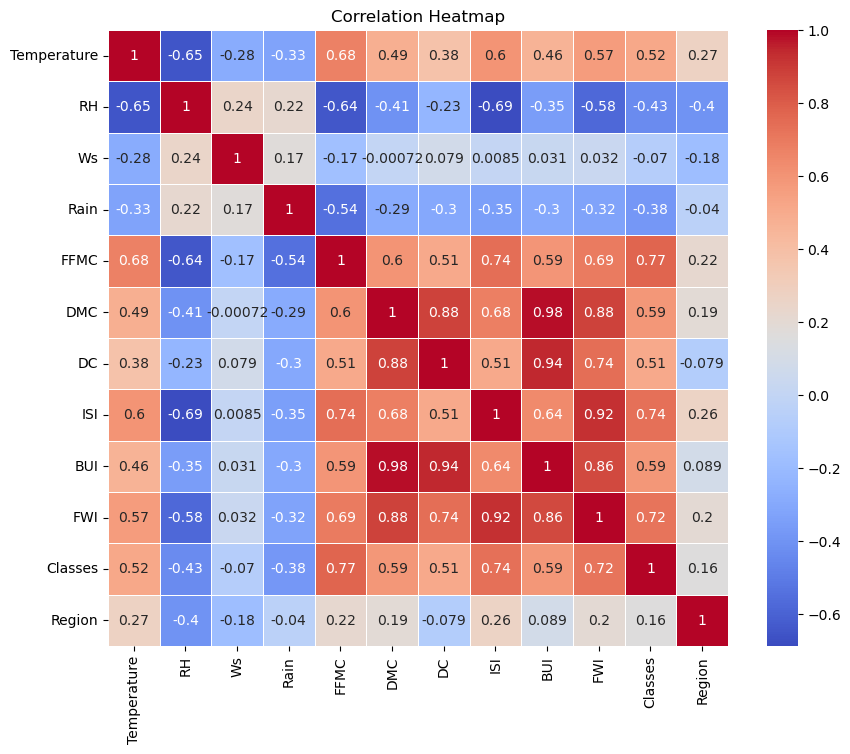

EDA Complete. Clean dataset saved successfully!


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# 1. LOAD THE DATASET
dataset = pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv", header=1)

# 2. DATA CLEANING

# Create the 'Region' column
dataset.loc[:122, "Region"] = 0
dataset.loc[122:, "Region"] = 1
df = dataset

# Drop missing values (This removes the "Sidi-Bel Abbes Region Dataset" title row)
df = df.dropna().reset_index(drop=True)

# --- THE FIX IS HERE ---
# We verify if there is any row where 'day' is written as "day" (the duplicate header)
# We remove it by keeping only rows where 'day' is NOT equal to 'day'
df = df[df['day'] != 'day']
# -----------------------

# Fix column names
df.columns = df.columns.str.strip()

# Change data types to numbers
# Now this will work because the text "day" is gone!
df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']] = df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']].astype(int)
df[['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Region']] = df[['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Region']].astype(float)

# Clean the 'Classes' column
df['Classes'] = df['Classes'].str.strip()
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0, 1)

# 3. EXPLORATORY DATA ANALYSIS (EDA)

# Pie Chart
percentage = df['Classes'].value_counts(normalize=True) * 100
classlabels = ["Fire", "Not Fire"]
plt.figure(figsize=(12, 7))
plt.pie(percentage, labels=classlabels, autopct='%1.1f%%')
plt.title("Pie Chart of Classes")
plt.show()

# Correlation Heatmap
df_corr = df.drop(['day', 'month', 'year'], axis=1)
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# 4. SAVE THE CLEAN DATA
df.to_csv("Algerian_forest_fires_cleaned_dataset.csv", index=False)

print("EDA Complete. Clean dataset saved successfully!")